
# Weekly Challenge: Full EDA on a Messy Dataset
***Dataset: Titanic (`train.csv`) — Kaggle Titanic: Machine Learning from Disaster***

***Objective:*** Analyze the raw Titanic dataset, assess its data quality, clean it responsibly, explore important patterns, and identify actionable insights and modeling risks.
### Task 1: Load and Profile the Raw Data
***Step 1.1: Import Libraries***

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("data/train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Step 1.3: Check Dataset Shape
The shape of the dataset is checked to determine the number of observations and variables available for analysis.

In [6]:
df.shape

(891, 12)

### Step 1.4: Check Column Names
The column names are inspected to understand the variables available in the dataset.

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

### Step 1.5: Check Data Types
The data type of each column is examined to distinguish numerical and categorical variables and identify potential type issues.

In [8]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

### Step 1.6: Dataset Information
The dataset information is examined to determine the number of non-null observations and the data type of each variable.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Step 1.7: Check Missing Values
Missing values are examined for every column to assess data completeness and identify variables that may require cleaning.

In [49]:
Missing_Values= df.isnull().sum()
Missing_Percentage= df.isnull().mean() * 100
print("Missing Values:")
print(Missing_Values)

print("\nMissing Percentage:")
print(Missing_Percentage)

Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Sex_num        0
dtype: int64

Missing Percentage:
PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
Sex_num        0.0
dtype: float64


**Observation:** `Cabin` is missing roughly 77% of its values, `Age` is missing roughly 20%, and `Embarked` is missing only 2 rows. These three columns will drive most of the cleaning decisions in Task 2.

### Step 1.8: Check Duplicate Records
Duplicate rows are checked because repeated observations can distort statistical analysis and potentially bias a machine-learning model.

In [11]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

### Step 1.9: Descriptive Statistics
Descriptive statistics are examined to understand the central tendency, spread, and range of the numerical variables.

In [12]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Step 1.10: Check Target Variable Distribution
The unique values and frequency of the `Survived` variable are examined because it is the target variable for potential predictive modeling.

In [13]:
df["Survived"].value_counts().sort_index()


Survived
0    549
1    342
Name: count, dtype: int64

**Observation:** About 38% of passengers in the training set survived (342 of 891), so the classes are imbalanced but not extreme — this is worth remembering when evaluating a future classifier (accuracy alone would be a weak metric).

### Step 1.11: Check Unique Values
The number of unique values in each column is examined to better understand the structure of the dataset and identify variables with limited or unusual categories.

In [14]:
df.nunique().sort_values()

Survived         2
Sex              2
Pclass           3
Embarked         3
Parch            7
SibSp            7
Age             88
Cabin          147
Fare           248
Ticket         681
PassengerId    891
Name           891
dtype: int64

### Task 1 Summary
The raw Titanic dataset was successfully loaded and profiled. The dataset's shape, column names, data types, missing values, duplicate records, descriptive statistics, and unique values were examined.

Key findings from profiling:
- The dataset has **891 rows and 12 columns**.
- Three columns have missing values: **`Cabin` (~77%)**, **`Age` (~20%)**, and **`Embarked` (~0.2%)**.
- No duplicate rows are present.
- `PassengerId`, `Name`, and `Ticket` are high-cardinality identifier-like columns that carry little direct predictive signal on their own.

These findings will guide the cleaning decisions in Task 2.

## Task 2: Clean the Dataset
The raw dataset is cleaned by addressing missing values, data types, duplicate records, and potential outliers. Each cleaning decision is supported by a clear rationale to preserve the reliability of the analysis.

### Step 2.1: Recheck Missing Values
Missing values are checked again before cleaning to determine which variables require treatment.

In [15]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Missing-value percentage

In [16]:
df.isnull().mean().mul(100).round(2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

### Step 2.2: Handle Missing Values

**`Age` (~20% missing)**
Decision:Impute missing Age values with the single overall median Age (28.0).
Rationale: The median is robust to the right-skewed tail in Age (max = 80) and provides a simple, low-distortion fill for a moderate amount of missingness (~20%), without introducing the added complexity of group-wise imputation.

**`Cabin` (~77% missing)**
Decision: Drop the Cabin column.
Rationale: About 77% of the values are missing, so filling them would be unreliable and could create false information.

**`Embarked` (2 missing)**
Decision: Impute the 2 missing values with the **mode** (most frequent port).
Rationale: Only 2 rows are affected, and the mode is a safe, low-impact fill for a categorical variable with such a small missing count.

### Age Missing Value

In [17]:
# 891 total
# 714 available
# 177 missing
# Calculate the median age before imputation
age_median = df["Age"].median()

print("Median Age:", age_median)

Median Age: 28.0


***Replace missing Age values with the median***

In [18]:
df["Age"] = df["Age"].fillna(age_median)

***Verify that Age has no missing values***

In [19]:
df["Age"].isnull().sum()

np.int64(0)

***Age missing values were replaced with the median to retain observations while reducing the influence of extreme ages***

### Missing Embarked
***Total = 891***

***Missing = 2***

***Missing % ≈ 0.22%***

 ***Embarked is a categorical varriable , that's why we use mode rather than median***

In [20]:
# Find the most frequent Embarked category
embarked_mode = df["Embarked"].mode()[0]

print("Mode of Embarked:", embarked_mode)

Mode of Embarked: S


In [21]:
# Replace missing Embarked values with the mode
df["Embarked"] = df["Embarked"].fillna(embarked_mode)

In [22]:
df["Embarked"].isnull().sum()

np.int64(0)

### Cabin

In [23]:
# Drop Cabin because of excessive missingness
df = df.drop(columns=["Cabin"])

***Cabin was dropped because approximately 77% of its values are missing, making reliable imputation impractical and potentially introducing artificial information***

### Step 2.3: Check and Fix Data Types
Decision: `Survived`, `Pclass`, `Sex`, and `Embarked` are treated as **categorical** variables even though `Survived`/`Pclass` are stored as integers, since their numeric values represent categories, not quantities.
Rationale: Correct typing prevents these columns from being mistakenly treated as continuous measurements during analysis or modeling.

In [24]:
# Check remaining missing values after cleaning
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Step 2.4: Check Duplicate Records
Check for exact duplicate rows before removing any records.

In [25]:
df.duplicated().sum()
df.duplicated().sum()


np.int64(0)

### Step 2.5: Handle Duplicate Records
Decision: No duplicate rows were found, so no records were removed.
Rationale: The dataset contains only unique passenger records.

### Step 2.6: Detect Outliers Using IQR
Potential outliers are identified using the IQR method on the numeric columns.

In [26]:
numeric_cols = ["Age", "Fare", "SibSp", "Parch"]

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_counts = (
    ((df[numeric_cols] < Q1 - 1.5 * IQR) |
     (df[numeric_cols] > Q3 + 1.5 * IQR))
    .sum()
)

outlier_counts.sort_values(ascending=False)


Parch    213
Fare     116
Age       66
SibSp     46
dtype: int64

### Step 2.7: Handle Outliers
Decision: Potential outliers in `Fare`, `Parch`, `SibSp`, and `Age` were **retained** rather than removed.
Rationale: The extreme `Fare` values correspond to genuine first-class/group bookings, and large `SibSp`/`Parch` values correspond to real large families. These are legitimate variation, not data-entry errors, so removing them would discard real signal (and potentially bias survival analysis against large families or high-fare passengers).

### Step 2.8: Verify the Cleaned Dataset
The dataset is rechecked after cleaning to confirm that no missing values (outside the intentionally dropped `Cabin`) remain and no duplicates were introduced.

In [27]:
print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())


Shape: (891, 11)
Duplicate rows: 0


### Task 2 Summary
The dataset was checked for missing values, incorrect data types, duplicate records, and potential outliers.

- `Age` was imputed using the overall median (28.0).
- `Cabin` was dropped due to ~77% missingness, making reliable imputation impractical.
- `Embarked` was imputed with its mode (only 2 rows affected).
- `Survived`, `Pclass`, `Sex`, and `Embarked` were converted to categorical dtypes.
- No duplicate records were found.
- Outliers in `Fare`, `SibSp`, `Parch`, and `Age` were identified but retained, since they represent genuine passenger variation rather than data errors.

## Task 3: Exploratory Data Analysis
Explore the cleaned dataset to identify distributions, patterns, relationships, and differences in survival outcomes.

### Step 3.1: Univariate Analysis
Examine the distribution and summary statistics of the numerical variables.

In [28]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,891.0,29.361582,13.019697,0.42,22.0000,28.0000,35.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


### Step 3.2: Survival Distribution
Examine how the target variable is distributed.

In [29]:
survival_counts =df["Survived"].value_counts().sort_index()
survival_counts

Survived
0    549
1    342
Name: count, dtype: int64

In [30]:
# 0 → Did not survive
# 1 → Survived

### Step 3.3: Correlation Analysis
Examine relationships between numerical variables (with `Sex` numerically encoded for this check) and identify variables associated with survival.

In [31]:
df["Sex_num"] = df["Sex"].map({"male": 0, "female": 1})

correlation = df[
    ["Survived", "Sex_num", "Pclass", "Age", "SibSp", "Parch", "Fare"]
].corr()

print(correlation["Survived"].sort_values(ascending=False))

Survived    1.000000
Sex_num     0.543351
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.064910
Pclass     -0.338481
Name: Survived, dtype: float64


### Step 3.4: Calculate the percentage of passengers in each survival category

In [32]:
survival_rate = df["Survived"].mean() * 100

print(survival_rate)

38.38383838383838


## Task4: Data Visualization

### Step 4.1:Visualize overall survival

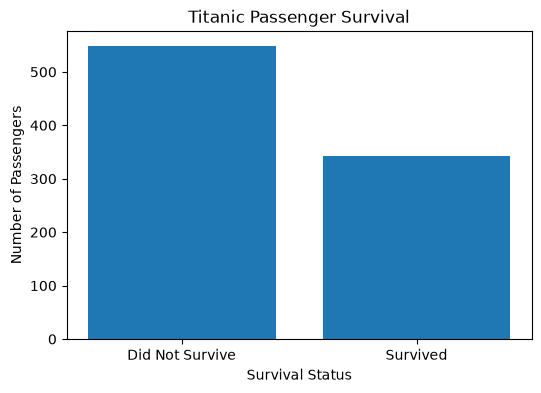

In [33]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["Did Not Survive", "Survived"],
    survival_counts.values
)

plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.title("Titanic Passenger Survival")

plt.show()

### Step 4.2:Passenger Class vs Survival

***Calculate survival rate for each passenger class***

In [34]:
survival_by_class = df.groupby("Pclass")["Survived"].mean() * 100

survival_by_class

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [35]:
# why .mean()?

# 0 = No
# 1 = Yes

# (1 + 1 + 0 + 0 + 1) / 5 = 0.60
# mean*100 = 60%

### Visualize survival rate by passenger class

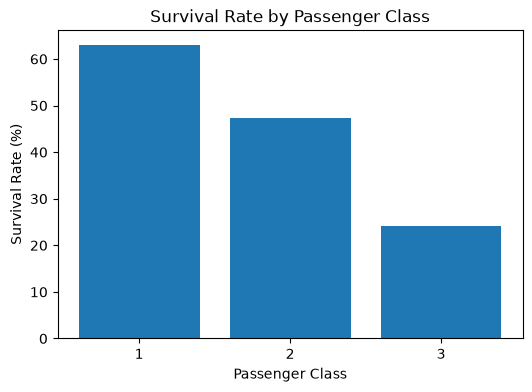

In [36]:
plt.figure(figsize=(6, 4))

plt.bar(
    survival_by_class.index.astype(str),
    survival_by_class.values
)

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Passenger Class")

plt.show()

***Survival rates differed substantially across passenger classes, with first-class passengers having the highest survival rate and third-class passengers having the lowest. This suggests that passenger class was strongly associated with survival in the dataset***

### Step 4.3:Sex vs Survival

***Question: Did survival rates differ between male and female passengers?***

In [37]:
survival_by_sex = df.groupby("Sex")["Survived"].mean() * 100

survival_by_sex

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

In [38]:
### Visualize survival rate by sex

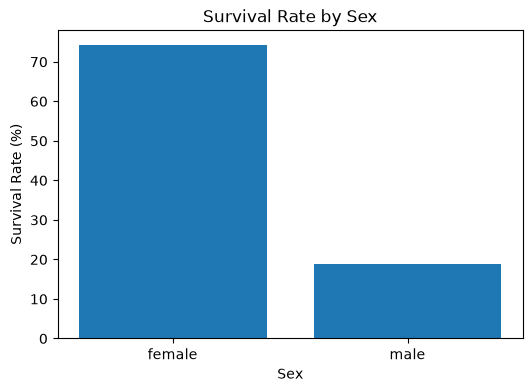

In [39]:
plt.figure(figsize=(6, 4))

plt.bar(
    survival_by_sex.index,
    survival_by_sex.values
)

plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Sex")

plt.show()

### Step 4.4: Sex + Passenger Class vs Survival
***Question: How did survival differ by both sex and passenger class?***

In [40]:
# Calculate survival rate by passenger class and sex
survival_by_class_sex = (
    df.groupby(["Pclass", "Sex"])["Survived"]
    .mean()
    .unstack()
    * 100
)

survival_by_class_sex

Sex,female,male
Pclass,,
1,96.808511,36.885246
2,92.105263,15.740741
3,50.000000,13.544669


In [41]:
### Plot survival rate by passenger class and sex

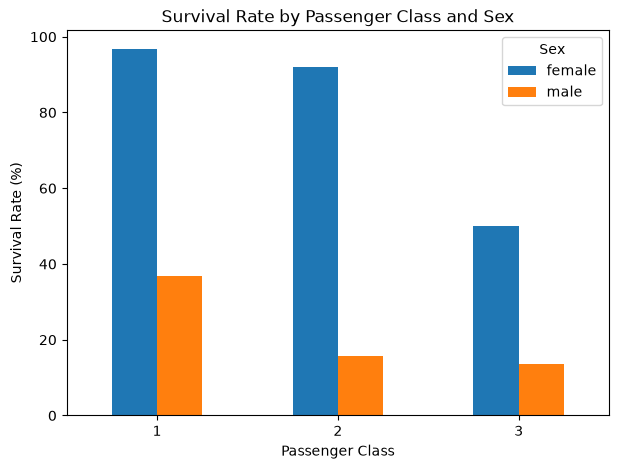

In [42]:
survival_by_class_sex.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Passenger Class and Sex")
plt.xticks(rotation=0)
plt.legend(title="Sex")

plt.show()

### Step 4.5:Age Distribution and Survival
***Question: How does passenger age differ between survivors and non-survivors?***

In [43]:
# Compare age statistics between survivors and non-survivors
df.groupby("Survived")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,30.028233,12.499986,1.00,23.0,28.0,35.0,74.0
1,342.0,28.291433,13.764425,0.42,21.0,28.0,35.0,80.0


***Compare median age by survival status***

In [44]:
df.groupby("Survived")["Age"].median()

Survived
0    28.0
1    28.0
Name: Age, dtype: float64

In [45]:
# Age distributions for survivors and non-survivors overlap substantially, with both groups having a median age of 28. Survivors were slightly younger on average, but age alone does not clearly separate the two groups.

<Figure size 700x500 with 0 Axes>

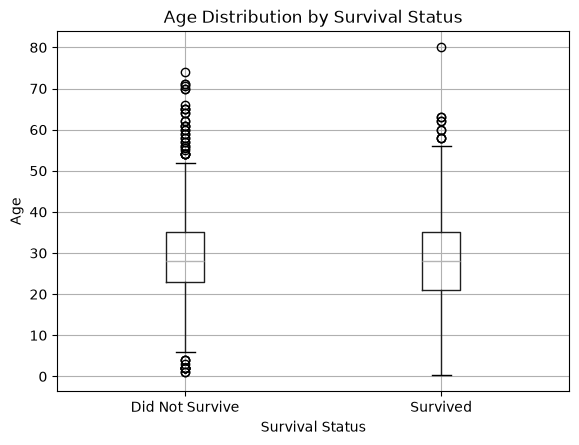

In [46]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column="Age",
    by="Survived"
)

plt.xlabel("Survival Status")
plt.ylabel("Age")
plt.title("Age Distribution by Survival Status")

plt.suptitle("")
plt.xticks([1, 2], ["Did Not Survive", "Survived"])

plt.show()

Visualization Interpretation: The age distributions of survivors and non-survivors overlap substantially, with both groups having a median age of 28. Survivors were slightly younger on average, but age alone does not clearly separate the two groups.

Data-quality note: The 177 missing Age values were imputed using the median age of 28. This may have slightly influenced the age distribution and should be considered when interpreting age-related patterns or using Age for modeling.

### Step 4.6: Fare and Survival

***Compare fare statistics between survivors and non-survivors***

In [47]:
df.groupby("Survived")["Fare"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,22.117887,31.388207,0.0,7.8542,10.5,26.0,263.0000
1,342.0,48.395408,66.596998,0.0,12.4750,26.0,57.0,512.3292


<Figure size 700x500 with 0 Axes>

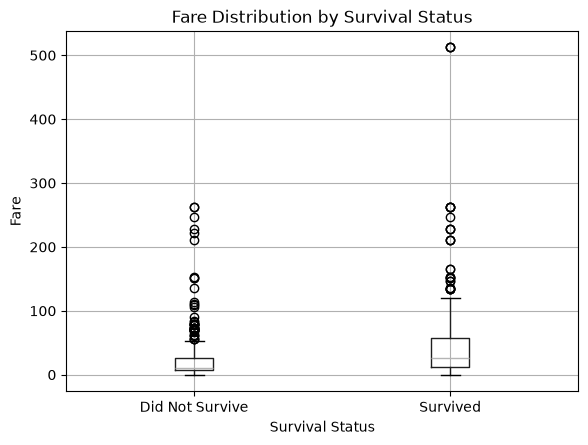

In [48]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column="Fare",
    by="Survived"
)

plt.xlabel("Survival Status")
plt.ylabel("Fare")
plt.title("Fare Distribution by Survival Status")

plt.suptitle("")
plt.xticks([1, 2], ["Did Not Survive", "Survived"])

plt.show()

## Key Findings

### Finding 1 — Class + Gender Interaction

**Survival depended on more than gender alone.** Female passengers had high survival rates in first and second class (96.8% and 92.1%), but female survival dropped to 50% in third class. Male survival remained much lower across all classes, ranging from 13.5% to 36.9%. This indicates that passenger class and gender jointly shaped survival outcomes.

### Finding 2 — Age Was Not a Strong Standalone Predictor

**Age alone did not clearly separate survivors from non-survivors.** Both groups had a median age of 28, and their distributions overlapped substantially. Survivors were slightly younger on average, but the difference was not large enough to make age a strong standalone separator.

### Finding 3 — Class Had a Substantial Survival Gradient

**Passenger class showed a strong survival gradient.** Survival was approximately 63% in first class, 47% in second class, and only 24% in third class. The large difference suggests that socioeconomic position and access to resources were strongly associated with survival in this dataset.

### Data-quality/modeling risk

***Cabin is highly incomplete.*** Approximately 77% of cabin values are missing, making direct use or imputation of cabin numbers unreliable. The missingness itself may contain information, so the analysis preserves it through a HasCabin indicator rather than inventing cabin values.